N: 746496
mean: -4.535379409790039
std: 3.453498363494873
min: -15.367790222167969
max: 8.322548866271973


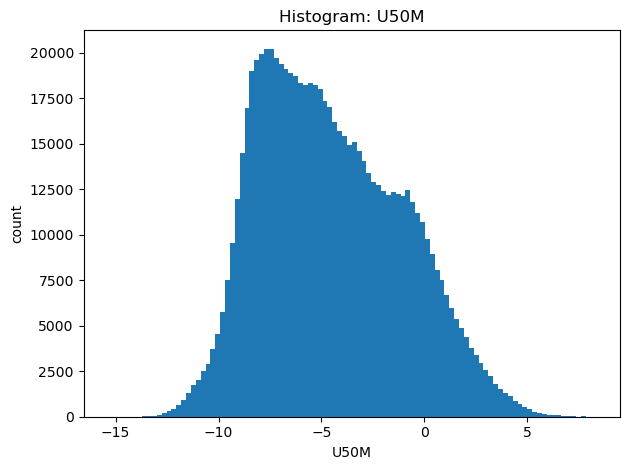

In [36]:
# This performs visual inspection on data chunks, compares the histogram vs the t-digest plots, 
# and compares the t-digest with its historically relevant digest from the database -- all visually
# Inspect the chunks of data used to compute t-digests for individual collections/vars

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

file = "da_sel_inst3_2d_asm_Nx|U50M|None|Strat5.nc4"
var = "U50M"

da = xr.open_dataarray(file, engine="netcdf4", decode_times=False) if var is None else xr.open_dataset(file, engine="netcdf4", decode_times=False)[var]

x = np.asarray(da).ravel()
x = x[np.isfinite(x)]  # drop NaN/Inf

print("N:", x.size)
print("mean:", float(x.mean()))
print("std:", float(x.std()))
print("min:", float(x.min()))
print("max:", float(x.max()))

plt.figure()
plt.hist(x, bins=100)
plt.title(f"Histogram: {var}")
plt.xlabel(var)
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [31]:
# now inspect the corresponding t-digest computed and saved

In [37]:
import pandas as pd
#import dask

path = "/home/sadhika8/JupyterLinks/nobackup/quads_data/GEOSFP/2023/01/test_2023-01-01.pkl"
lst = pd.read_pickle(path)

print(type(lst))
print("len:", len(lst))

print(len(lst))
print(lst[0].keys())

<class 'list'>
len: 224
224
dict_keys(['id_key', 'centroids', 'quantiles'])


In [38]:
#print(sorted(lst[108]["quantiles"]))

In [39]:
for ind, elem in enumerate(lst):
    if elem["id_key"] == "inst3_2d_asm_Nx|U50M|None|Strat5":
        #print (elem["quantiles"])
        y, x = elem["quantiles"]
        print(y)

[-15.367790222167969, -15.322679904541015, -14.533589852905273, -13.256668210336402, -12.277768095170535, -10.903290878591692, -8.67471815643065, -8.196519789709626, -7.743667294705608, -7.303509743520943, -6.855277719737622, -6.399680457211183, -5.916041995176695, -5.422716946415046, -4.949818918584386, -4.42292577785242, -3.8784774868617435, -3.2959055333499667, -2.670326092804624, -1.9836202891935273, -1.2614614526606298, -0.5308910547800689, 0.3030275175587005, 3.5985077538314356, 5.476601472170498, 6.958067657609395, 7.981802069853899, 8.316182043396566, 8.322548866271973]


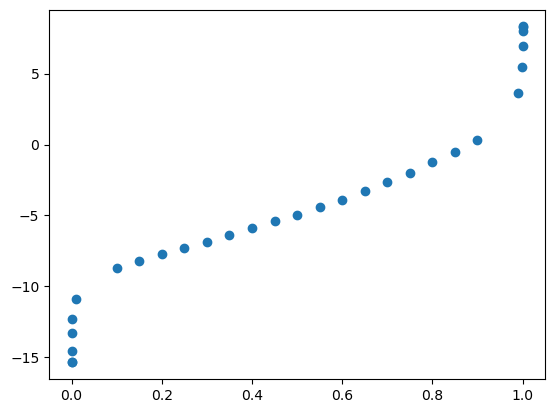

In [40]:
plt.scatter(x, y)

In [52]:
# now compare it to the database computed by the main code

In [42]:
import sqlite3, pickle, pathlib

db = "/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"
with sqlite3.connect(db) as conn:
    cur = conn.cursor()
    #cur.execute("SELECT COUNT(*) FROM geosfp;")
    #print("rows:", cur.fetchone()[0])

    cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
    tables = [row[0] for row in cur.fetchall()]

    print("tables:", tables)

    for t in tables:
        cur.execute(f"PRAGMA table_info({t});")
        cols = [row[1] for row in cur.fetchall()]  # row[1] is column name
        print(f"{t} columns: {cols}")

tables: ['geosfp']
geosfp columns: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


In [49]:
# inputs you choose
model = "geosfp"          # table name, e.g. "geosfp"
year = 2024
month = 1                 # 1-12
id_string = "inst3_2d_asm_Nx|U50M|None|Strat5"

with sqlite3.connect(db) as conn:
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()

    cur.execute(
        f"""
        SELECT *
        FROM {model}
        WHERE year = ?
          AND month = ?
          AND id_string = ?
        LIMIT 1
        """,
        (year, month, id_string),
    )

    row = cur.fetchone()
    if row is None:
        print("No match found.")
    else:
        d = dict(row)
        print("Matched row keys:", list(d.keys()))

        y, x = d["quantiles"], d["quantile_list"]
        if isinstance(y, (bytes, bytearray)): y = pickle.loads(y)
        if isinstance(x, (bytes, bytearray)): x = pickle.loads(x)

Matched row keys: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


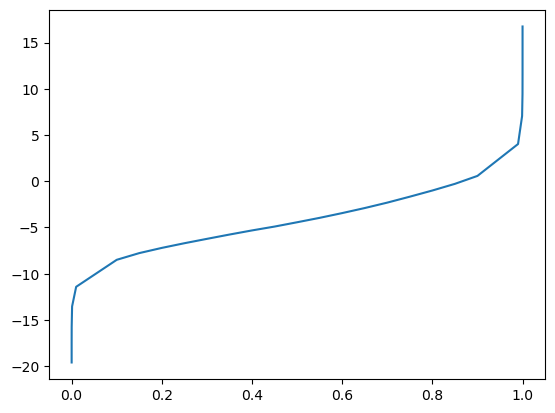

In [51]:
plt.plot(x, y)